# Example usage of `financial_analysis_tool`

This notebook shows how to use the package from Python. The same results are also available from the command line, as described in the README file.

In [32]:
import matplotlib.pyplot as plt

from financial_analysis_tool import (
    BalanceForecast,
    InvestmentRule,
    SavingsRateRule,
    TransactionHistory,
    find_recurring_payments,
    give_advice,
    save_all_plots,
    split_expenses,
    total_monthly_cost,
)

## Loading the data

`TransactionHistory.from_csv()` loads the bundled sample data. To analyze your own file, pass its path, for example `TransactionHistory.from_csv("my_bank.csv")`.

In [33]:
history = TransactionHistory.from_csv()
history

TransactionHistory(663 transactions, 2018-01-01 to 2019-09-30)

In [34]:
history.transactions.head()

,Date,Description,Amount,Transaction Type,Category,Account Name,Month,Signed Amount
0,2018-01-01,Amazon,11.11,debit,Shopping,Platinum Card,2018-01,-11.11
1,2018-01-02,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking,2018-01,-1247.44
2,2018-01-02,Thai Restaurant,24.22,debit,Restaurants,Silver Card,2018-01,-24.22
3,2018-01-04,Netflix,11.76,debit,Movies & DVDs,Platinum Card,2018-01,-11.76
4,2018-01-05,American Tavern,25.85,debit,Restaurants,Silver Card,2018-01,-25.85


## Summary

How much was earned, spent and saved over the whole period, the statistics per month, and where most of the money went.

In [35]:
print(f"Total income:   {history.total_income:12,.2f}")
print(f"Total spending: {history.total_spending:12,.2f}")
print(f"Net:            {history.net:12,.2f}")

Total income:      93,750.00
Total spending:    63,042.42
Net:               30,707.58


In [36]:
history.monthly_statistics().round(2)

,Mean,Median,Min,Max
Income,4464.29,4000.00,4000.00,6750.00
Spending,3002.02,2142.59,1736.43,10912.38
Net,1462.27,1910.56,-6912.38,4706.80


In [37]:
history.spending_by_category().head(5)

Category
Mortgage & Rent     24754.50
Home Improvement    19092.87
Groceries            2795.21
Utilities            2776.00
Restaurants          2613.02
Name: Signed Amount, dtype: float64

## Recurring payments

Bills and subscriptions paid about once a month with a stable amount in the last 12 months.

In [38]:
payments = find_recurring_payments(history)
for payment in payments:
    print(payment)
print(f"Total cost per month: {total_monthly_cost(payments):,.2f}")

RecurringPayment('Mortgage Payment', average of 1127.30 per month, paid in 12 out of the last 12 months)
RecurringPayment('Internet Service Provider', average of 75.08 per month, paid in 12 out of the last 12 months)
RecurringPayment('State Farm', average of 75.00 per month, paid in 12 out of the last 12 months)
RecurringPayment('Phone Company', average of 71.12 per month, paid in 12 out of the last 12 months)
RecurringPayment('Power Company', average of 60.00 per month, paid in 12 out of the last 12 months)
RecurringPayment('Gas Company', average of 36.58 per month, paid in 12 out of the last 12 months)
RecurringPayment('City Water Charges', average of 35.00 per month, paid in 12 out of the last 12 months)
RecurringPayment('Netflix', average of 12.73 per month, paid in 11 out of the last 12 months)
RecurringPayment('Spotify', average of 10.69 per month, paid in 12 out of the last 12 months)
Total cost per month: 1,503.51


## Balance forecast

The forecast starts from the current balance and adds the median monthly net of the last 12 months for every future month.

In [39]:
forecast = BalanceForecast(history, starting_balance=5000)
forecast.predict(6)

,Month,Balance
0,2019-10,6991.005
1,2019-11,8982.010
2,2019-12,10973.015
3,2020-01,12964.020
4,2020-02,14955.025
5,2020-03,16946.030


In [40]:
print(f"Balance after 12 months: {forecast.balance_in(12):,.2f}")
print(f"Months until a balance of 20,000: {forecast.months_until(20000)}")

Balance after 12 months: 28,892.06
Months until a balance of 20,000: 8


The mean can be used instead of the median. However, the median is supposed to be more accurate:

In [41]:
mean_forecast = BalanceForecast(history, starting_balance=5000, method="mean")
print(f"Balance after 12 months: {mean_forecast.balance_in(12):,.2f}")
print(f"Months until a balance of 20,000: {mean_forecast.months_until(20000)}")

Balance after 12 months: 24,137.66
Months until a balance of 20,000: 10


## Recommendations

`give_advice` runs all recommendation rules on the last 12 months.

In [42]:
for number, message in enumerate(give_advice(history), start=1):
    print(f"{number}. {message}")

1. In the last 12 months, you saved 35.6% of your income, which meets the 20% target share, great job!
2. Recurring payments make up 71% of a typical month's spending, mainly Mortgage Payment, Internet Service Provider, State Farm, Phone Company, Power Company. Lowering these, for example by switching to a cheaper provider or renegotiating the contract, will greatly support your budget.
3. You pay for small subscriptions (Netflix, Spotify) costing 24.59 per month (295.08 per year) at current prices. Cancel the ones you rarely use.
4. You spent 615.25 per month on everyday purchases, mostly on Groceries (130.24), Restaurants (105.76), Home Improvement (97.58), Shopping (75.17), Gas & Fuel (73.17). Reducing them by 10% saves 61.53 per month (738.30 per year).
5. One-off expense(s) larger than a typical month's spending: Mike's Construction Co. (9,200.00). Save money in advance for such expenses.
6. First keep an emergency fund of 3 months of typical spending (6,391.11 needed to be saved)

The rules can also be chosen and adjusted, for example a savings target of 40% and an emergency fund of 6 months:

In [43]:
custom_rules = [SavingsRateRule(target_share=0.40), InvestmentRule(emergency_months=6)]
for message in give_advice(history, rules=custom_rules):
    print(message)

In the last 12 months, you saved only 35.6% of your income. To reach 40%, save 196.86 more per month, by lowering your everyday spending or cancelling unwanted subscriptions.
First keep an emergency fund of 6 months of typical spending (12,782.22 needed to be saved). At your typical monthly surplus of 1,991.01, this takes about 7 months if you are starting from zero. After that, consider investing the surplus regularly, for example in a diversified fund, instead of leaving it in a bank account.


## Spending groups

The recommendations are based on splitting the expenses of the last 12 months into recurring payments, one-off expenses and everyday purchases.

In [44]:
recurring, one_off, everyday = split_expenses(history.last_months(12))
print("Number of transactions in each group:")
print(f"Recurring payments: {len(recurring)}")
print(f"One-off expenses:   {len(one_off)}")
print(f"Everyday purchases: {len(everyday)}")

Number of transactions in each group:
Recurring payments: 107
One-off expenses:   1
Everyday purchases: 239


## Charts

The chart functions save PNG files and return their paths. Here all four charts are saved into the `plots` folder of the project and then shown.

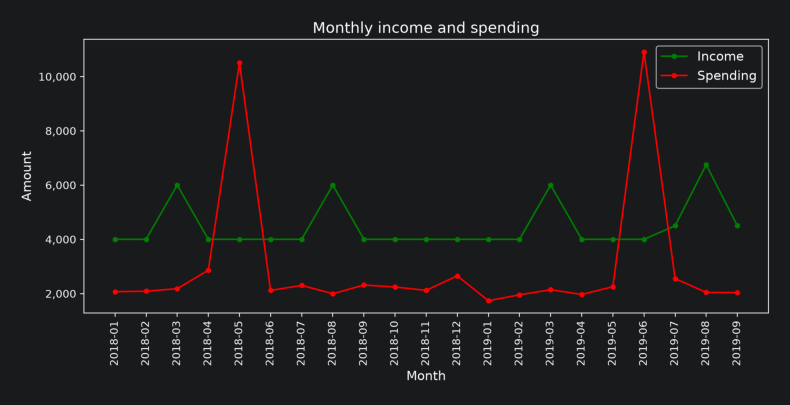

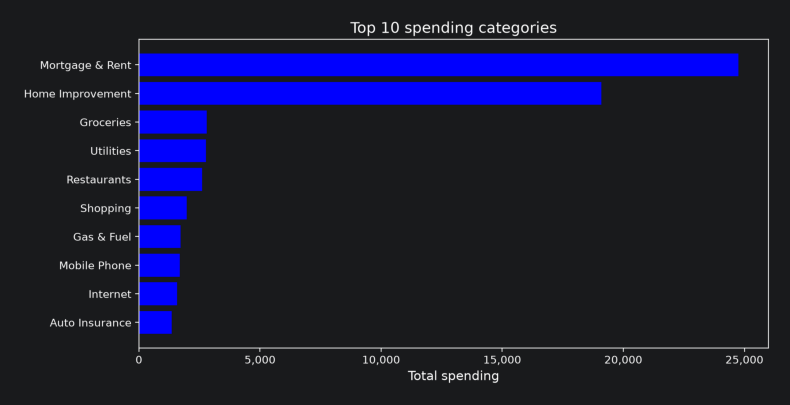

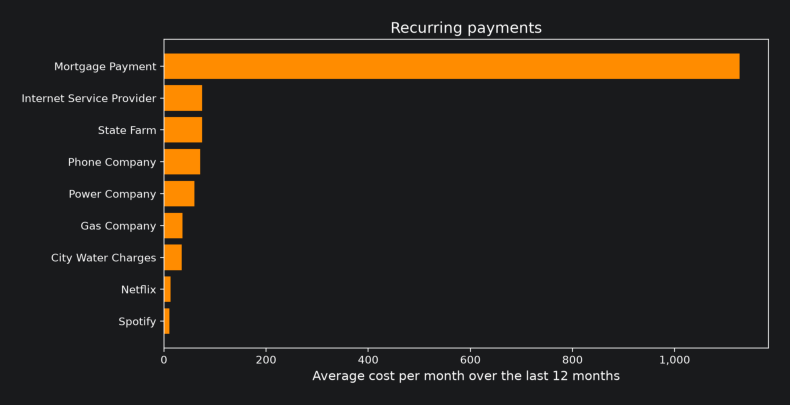

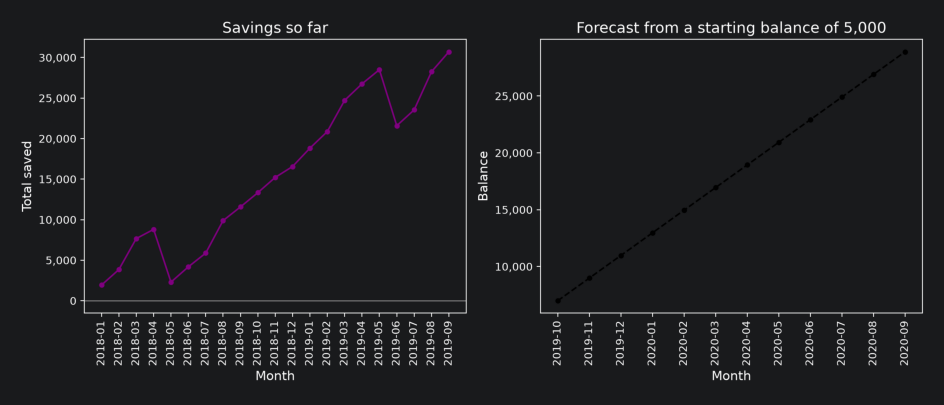

In [45]:
paths = save_all_plots(history, starting_balance=5000, output_dir="../plots")
for path in paths:
    plt.figure(figsize=(12, 5))
    plt.imshow(plt.imread(path))
    plt.axis("off")
    plt.show()